In [1]:
#Initial Data Inspection

# =============================================================================
# STEP 1: Import Required Libraries
# =============================================================================
# pandas is used for data manipulation and analysis.
# pathlib provides an operating-system independent way to construct file paths.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# Display Settings (EDA Only)
# =============================================================================
# Adjust pandas display options to ensure that descriptive statistics
# and DataFrames are shown completely during exploratory data analysis.
# These settings only affect the display and do not modify the data.
# Display all columns without truncation during exploratory analysis.
pd.set_option("display.max_columns", None)

# Remove the display width limitation for console output.
pd.set_option("display.width", None)

# Display full column contents without truncation.
pd.set_option("display.max_colwidth", None)


# =============================================================================
# STEP 2: Read the Dataset and Ensure Store ID Consistency
# =============================================================================
# The project assumes that all input files are stored in the same directory
# structure. Therefore, the file path is created dynamically using pathlib
# instead of hardcoding an absolute path.
# We have same store id in all files

raw_dir = Path("..") / "data" / "raw"
sales_data_path = raw_dir / "sales_data.csv"
future_data_path = raw_dir / "future_values.csv"
meta_data_path = raw_dir / "metadata.csv"

# Read the sales dataset.
# low_memory=False prevents pandas from inferring column types in chunks,
# which avoids unnecessary DtypeWarning messages for larger datasets.

sales_data = pd.read_csv(
    sales_data_path,
    low_memory=False
)

future_data = pd.read_csv(
    future_data_path,
    low_memory=False
)

meta_data = pd.read_csv(
    meta_data_path,
    low_memory=False
)

# Compute store id sets after the CSVs have been read to avoid NameError
sales_store = set(sales_data["store_id"])
future_store = set(future_data["store_id"])
meta_store = set(meta_data["store_id"])

print("Sales stores :", len(sales_store))
print("Future stores:", len(future_store))
print("Meta stores  :", len(meta_store))

print("\nSales == Future :", sales_store == future_store)
print("Sales == Meta   :", sales_store == meta_store)
print("Future == Meta  :", future_store == meta_store)

# =============================================================================
# STEP 3: Inspect Dataset Dimensions
# =============================================================================
# Understanding the size of the dataset is an important first step.
# The number of rows indicates the total number of observations,
# while the number of columns indicates the number of available variables.

print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(sales_data.shape)


# =============================================================================
# STEP 4: Inspect Dataset Structure
# =============================================================================
# info() provides a concise overview of the dataset, including:
# - column names
# - data types
# - number of non-missing observations
#
# This helps identify potential missing values and variables that require
# type conversion before further analysis.

print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
sales_data.info()


# =============================================================================
# STEP 5: Inspect Data Types
# =============================================================================
# Display the data type of each variable.
# This is useful to verify whether variables have been imported correctly.
# For example, the date column is typically read as an object and should later
# be converted into pandas datetime format.

print("\n" + "=" * 60)
print("VARIABLE DATA TYPES")
print("=" * 60)
print(sales_data.dtypes)

# =============================================================================
# STEP 6: Display Sample Observations
# =============================================================================
# Displaying the first few rows provides a quick visual inspection of the
# dataset and helps verify that the variables contain reasonable values.

print("\n" + "=" * 60)
print("FIRST FIVE OBSERVATIONS")
print("=" * 60)
print(sales_data.head())


# =============================================================================
# STEP 7: Convert the Date Variable
# =============================================================================
# The date column is currently stored as an object (string).
# Converting it to datetime enables chronological sorting,
# time-based aggregation and extraction of calendar features
# (e.g. weekday, month and week), which are essential for time series analysis.

sales_data["date"] = pd.to_datetime(sales_data["date"])


# =============================================================================
# STEP 8: Verify Date Range and Continuity Check
# =============================================================================
# Inspect the temporal coverage of the dataset.
# Knowing the start and end dates provides an overview of the available
# historical period and helps verify that the dataset has been loaded correctly.
# Ensure that there is no gaps in time series

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)
print("Start Date:", sales_data["date"].min())
print("End Date  :", sales_data["date"].max())
print("Unique Dates:", sales_data["date"].nunique())

print("\n" + "=" * 60)
print("DATE CONTINUITY CHECK")
print("=" * 60)

stores_with_gaps = {}

for store, group in sales_data.groupby("store_id"):

    dates = group["date"].sort_values()

    expected = pd.date_range(
        start=dates.min(),
        end=dates.max(),
        freq="D"
    )

    missing = expected.difference(dates)

    if len(missing) > 0:

        stores_with_gaps[store] = len(missing)

print("Stores checked:",
      sales_data["store_id"].nunique())

print("Stores with missing dates:",
      len(stores_with_gaps))

if len(stores_with_gaps) == 0:

    print("All stores have complete daily timelines.")

else:

    print("\nFirst 10 stores with gaps:")

    for store, n in list(stores_with_gaps.items())[:10]:

        print(f"{store}: {n} missing days")

print("Start:", sales_data["date"].min())
print("End:  ", sales_data["date"].max())

sales_data["date"] = pd.to_datetime(sales_data["date"])

results = []

for store, group in sales_data.groupby("store_id"):
    actual_dates = pd.DatetimeIndex(group["date"].sort_values().unique())

    expected_dates = pd.date_range(
        start=actual_dates.min(),
        end=actual_dates.max(),
        freq="D"
    )

    missing_dates = expected_dates.difference(actual_dates)

    results.append({
        "store_id": store,
        "start_date": actual_dates.min(),
        "end_date": actual_dates.max(),
        "actual_days": len(actual_dates),
        "expected_days": len(expected_dates),
        "missing_days": len(missing_dates)
    })

date_check = pd.DataFrame(results)

display(date_check.head())

summary = (
    date_check["missing_days"]
    .value_counts()
    .sort_index()
    .reset_index()
)

summary.columns = ["missing_days", "number_of_stores"]

display(summary)

# =============================================================================
# STEP 9: Check Missing Values
# =============================================================================
# Missing values may negatively affect both exploratory analysis and model
# training. Therefore, the number of missing observations is calculated
# for every variable before any preprocessing is performed.

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(sales_data.isnull().sum())


# =============================================================================
# STEP 10: Check Duplicate Observations
# =============================================================================
# Duplicate records can introduce bias into model estimation.
# Both complete duplicates and duplicate store-date combinations should be
# investigated.

print("\n" + "=" * 60)
print("DUPLICATE OBSERVATIONS")
print("=" * 60)
print("Entire duplicated rows:",
      sales_data.duplicated().sum())

print("Duplicate store-date pairs:",
      sales_data.duplicated(
          subset=["store_id", "date"]
      ).sum())


# =============================================================================
# STEP 11: Descriptive Statistics
# =============================================================================
# Descriptive statistics are reported separately for numerical,
# categorical and datetime variables.
#
# Splitting the summaries by data type improves readability and provides
# statistics that are meaningful for each variable type.

# -------------------------------------------------------------------------
# Numerical Variables
# -------------------------------------------------------------------------
# Summary statistics for numerical variables provide information about
# central tendency, variability and potential extreme values.

print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)
print(sales_data.describe(include="number"))


# -------------------------------------------------------------------------
# Categorical Variables
# -------------------------------------------------------------------------
# Summary statistics for categorical variables provide information about
# the number of unique categories, the most frequent category and its
# occurrence frequency.

print("\n" + "=" * 60)
print("CATEGORICAL SUMMARY")
print("=" * 60)
print(sales_data.describe(include="object"))


# =============================================================================
# STEP 12: Inspect Categorical Variables
# =============================================================================
# Display the distribution of categorical variables.
# Understanding category frequencies is useful for later feature engineering
# and evaluating whether some categories occur very infrequently.

print("\n" + "=" * 60)
print("STATE HOLIDAY DISTRIBUTION")
print("=" * 60)
print(sales_data["state_holiday"].value_counts(dropna=False))

print("\nOPEN STATUS (Count)")
print(sales_data["open"].value_counts())

print("\nOPEN STATUS (Percentage)")
print(
    sales_data["open"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPROMOTION STATUS")
print(sales_data["promo"].value_counts())
print(sales_data["promo"].value_counts(normalize=True))

print("\nSCHOOL HOLIDAY STATUS")
print(sales_data["school_holiday"].value_counts())
print(sales_data["school_holiday"].value_counts(normalize=True))



# =============================================================================
# STEP 13: Relationship Between Store Status and Sales
# =============================================================================
# Verify whether closed stores (open = 0) consistently report zero sales
# and zero customers. This validation helps identify whether closed-store
# observations should be treated differently during later modelling.

print("\n" + "=" * 60)
print("STORE STATUS VS SALES")
print("=" * 60)

print(
    sales_data.groupby("open")[["sales", "customers"]]
    .agg(["min", "max", "mean"])
)

closed_store = sales_data[sales_data["open"] == 0]

print(
    "\nClosed stores with non-zero sales:",
    (closed_store["sales"] != 0).sum()
)

print(
    "Closed stores with non-zero customers:",
    (closed_store["customers"] != 0).sum()
)


Sales stores : 676
Future stores: 676
Meta stores  : 676

Sales == Future : True
Sales == Meta   : True
Future == Meta  : True
DATASET DIMENSIONS
(624624, 8)

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624624 entries, 0 to 624623
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   store_id        624624 non-null  object
 1   date            624624 non-null  object
 2   sales           624624 non-null  int64 
 3   customers       624624 non-null  int64 
 4   open            624624 non-null  int64 
 5   promo           624624 non-null  int64 
 6   state_holiday   624624 non-null  object
 7   school_holiday  624624 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 38.1+ MB

VARIABLE DATA TYPES
store_id          object
date              object
sales              int64
customers          int64
open               int64
promo              int64
state_holiday     object
school_holiday  

,store_id,start_date,end_date,actual_days,expected_days,missing_days
0,store_1,2013-01-07,2015-07-19,924,924,0
1,store_10,2013-01-07,2015-07-19,924,924,0
2,store_100,2013-01-07,2015-07-19,924,924,0
3,store_101,2013-01-07,2015-07-19,924,924,0
4,store_102,2013-01-07,2015-07-19,924,924,0


,missing_days,number_of_stores
0,0,676



MISSING VALUES
store_id          0
date              0
sales             0
customers         0
open              0
promo             0
state_holiday     0
school_holiday    0
dtype: int64

DUPLICATE OBSERVATIONS
Entire duplicated rows: 0
Duplicate store-date pairs: 0

NUMERICAL SUMMARY
               sales      customers           open          promo  \
count  624624.000000  624624.000000  624624.000000  624624.000000   
mean     5747.860791     639.733232       0.832246       0.384199   
std      3771.558531     479.732220       0.373648       0.486406   
min         0.000000       0.000000       0.000000       0.000000   
25%      3786.000000     414.000000       1.000000       0.000000   
50%      5738.000000     611.000000       1.000000       0.000000   
75%      7794.000000     834.000000       1.000000       1.000000   
max     38722.000000    5494.000000       1.000000       1.000000   

       school_holiday  
count   624624.000000  
mean         0.171053  
std          0.376

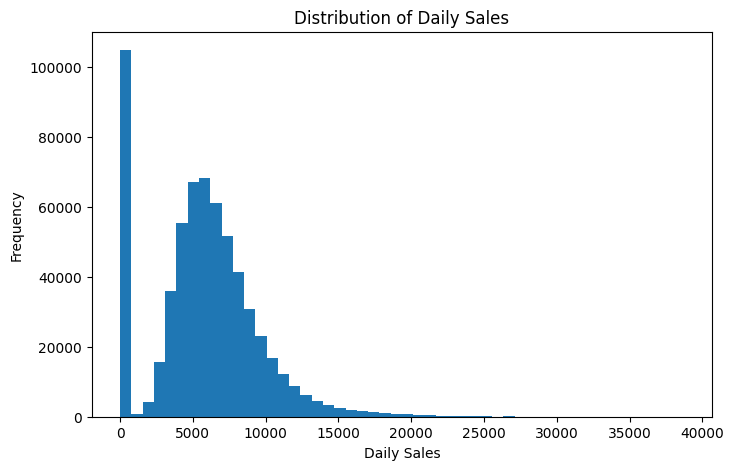

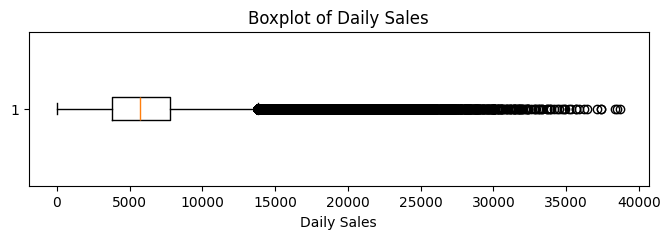


CORRELATION MATRIX
                         sales  customers         promo  school_holiday  \
sales                 1.000000   0.882172  4.515132e-01        0.076628   
customers             0.882172   1.000000  2.979785e-01        0.058447   
promo                 0.451513   0.297978  1.000000e+00        0.056926   
school_holiday        0.076628   0.058447  5.692594e-02        1.000000   
competition_distance -0.003036  -0.086075  1.071347e-16       -0.006446   

                      competition_distance  
sales                        -3.036429e-03  
customers                    -8.607517e-02  
promo                         1.071347e-16  
school_holiday               -6.446063e-03  
competition_distance          1.000000e+00  


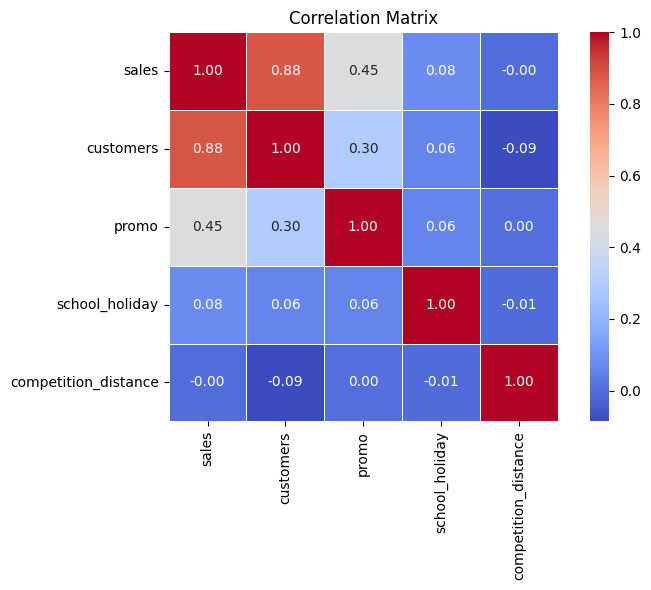

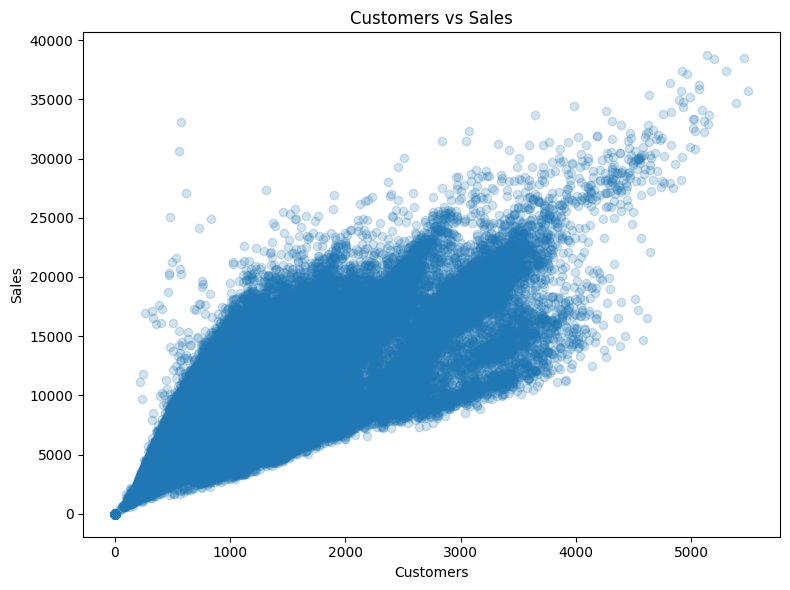


CORRELATION WITH SALES
sales                   1.000000
customers               0.882172
promo                   0.451513
school_holiday          0.076628
competition_distance   -0.003036
Name: sales, dtype: float64


In [2]:
#sales data  EDA

# =============================================================================
# STEP 16: Sales Distribution
# =============================================================================
# Visualise the distribution of daily sales to understand
# its overall shape, spread and potential skewness.

plt.figure(figsize=(8,5))

plt.hist(
    sales_data["sales"],
    bins=50
)

plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")

plt.savefig(
    "../results/figures/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8,2))

plt.boxplot(
    sales_data["sales"],
    vert=False
)

plt.title("Boxplot of Daily Sales")
plt.xlabel("Daily Sales")

plt.savefig(
    "../results/figures/sales_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# Correlation Analysis
# =============================================================================

# Merge competition distance for correlation analysis
corr_data = sales_data.merge(
    meta_data[["store_id", "competition_distance"]],
    on="store_id",
    how="left"
)

# Select numerical variables
corr_columns = [
    "sales",
    "customers",
    "promo",
    "school_holiday",
    "competition_distance"
]

correlation = corr_data[corr_columns].corr()

print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(correlation)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    corr_data["customers"],
    corr_data["sales"],
    alpha=0.2
)

plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CORRELATION WITH SALES")
print("=" * 60)

print(
    correlation["sales"]
    .sort_values(ascending=False)
)


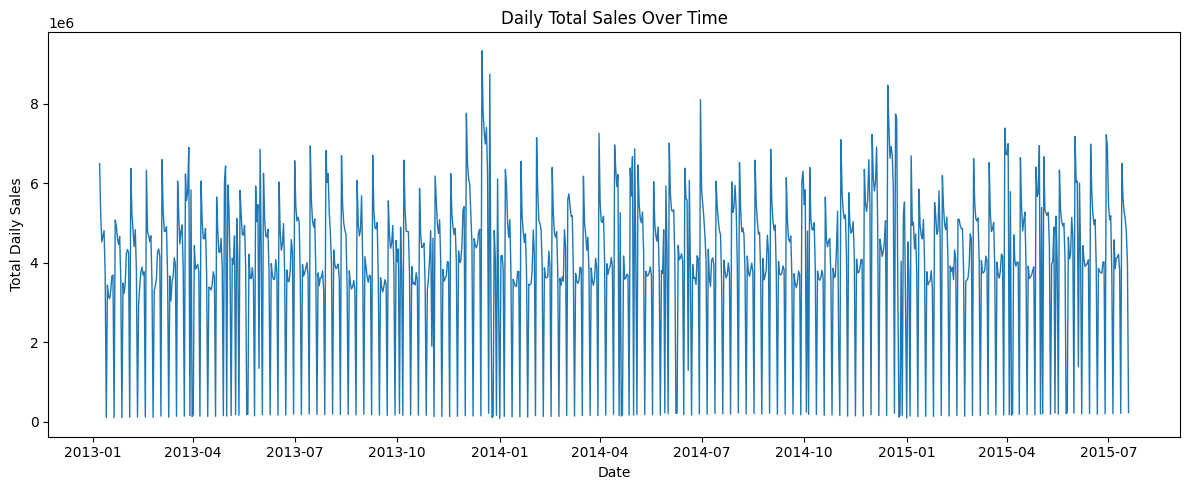

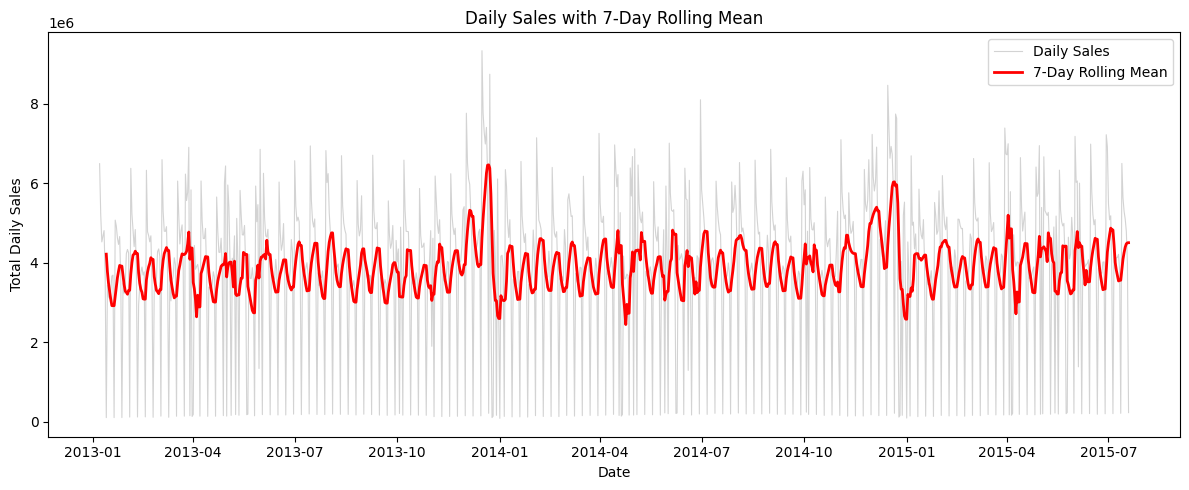

In [11]:
# =============================================================================
# STEP 17: Daily Total Sales Trend
# =============================================================================
# Aggregate sales across all stores to examine
# the overall sales trend over time.

daily_sales = (
    sales_data
    .groupby("date", as_index=False)["sales"]
    .sum()
)
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    linewidth=1
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Sales")

plt.tight_layout()
plt.show()

#The aggregated daily sales exhibit a clear weekly seasonal pattern, with regular drops corresponding to store closures. No strong long-term upward or downward trend is observed over the study period, although several temporary sales peaks occur, likely associated with promotional campaigns or holiday periods.

# =============================================================================
# STEP 17.2: Daily Sales Trend with 7-Day Rolling Mean
# =============================================================================
# Apply a 7-day rolling average to smooth daily fluctuations
# and highlight the underlying sales trend.

daily_sales["rolling_7"] = (
    daily_sales["sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,5))

# Original daily sales
plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    color="lightgray",
    linewidth=0.8,
    label="Daily Sales"
)

# 7-day rolling mean
plt.plot(
    daily_sales["date"],
    daily_sales["rolling_7"],
    color="red",
    linewidth=2,
    label="7-Day Rolling Mean"
)

plt.title("Daily Sales with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Total Daily Sales")

plt.legend()

plt.tight_layout()

plt.show()

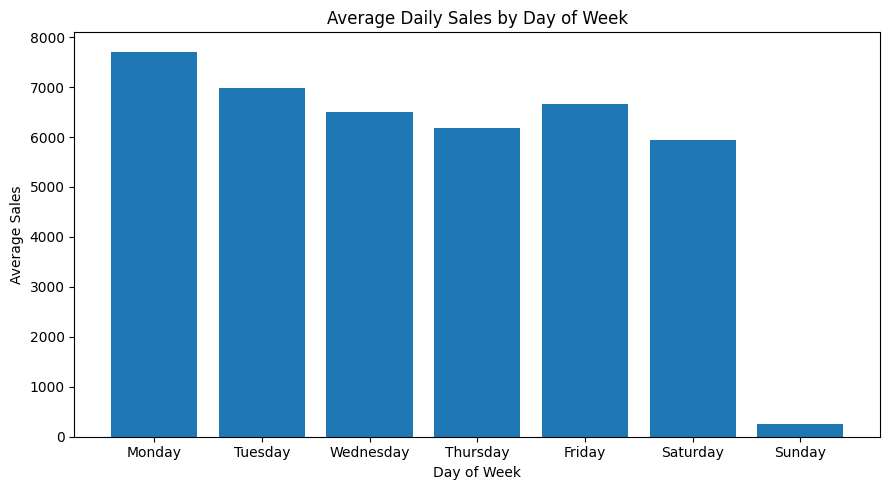

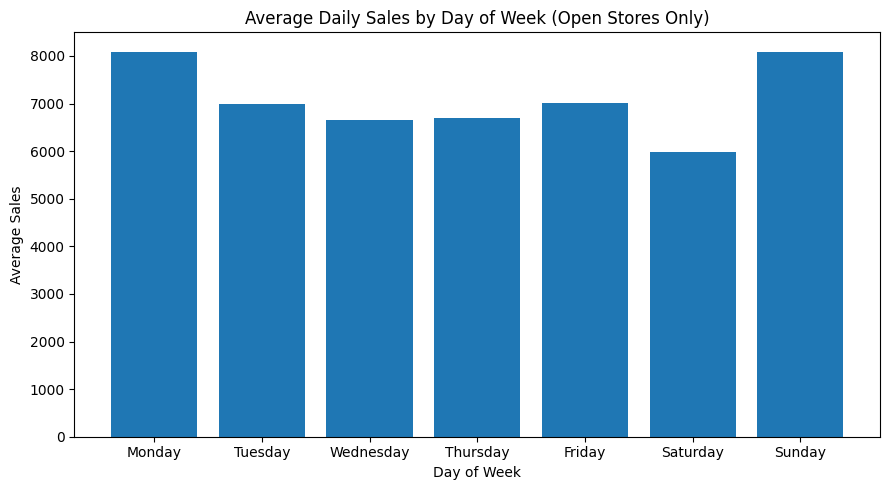

In [12]:
# =============================================================================
# STEP 18: Weekly Sales Pattern
# =============================================================================
# Examine average sales by day of week to identify
# weekly seasonality.

sales_data["weekday"] = sales_data["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = (
    sales_data
    .groupby("weekday")["sales"]
    .mean()
    .reindex(weekday_order)
)
plt.figure(figsize=(9,5))

plt.bar(
    weekly_pattern.index,
    weekly_pattern.values
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.tight_layout()

plt.show()

# =============================================================================
# STEP 18.2: Weekly Sales Pattern (Open Stores Only)
# =============================================================================
# Analyse weekly sales pattern after excluding closed stores.

open_sales = sales_data[sales_data["open"] == 1].copy()
open_sales["weekday"] = open_sales["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern_open = (
    open_sales
    .groupby("weekday")["sales"]
    .mean()
    .reindex(weekday_order)
)
plt.figure(figsize=(9,5))

plt.bar(
    weekly_pattern_open.index,
    weekly_pattern_open.values
)

plt.title("Average Daily Sales by Day of Week (Open Stores Only)")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.tight_layout()

plt.show()




PROMOTION EFFECT
        mean_sales  median_sales    std_sales   count
promo                                                
0      4402.777912        4648.0  3388.327078  384644
1      7903.782365        7496.0  3327.875615  239980


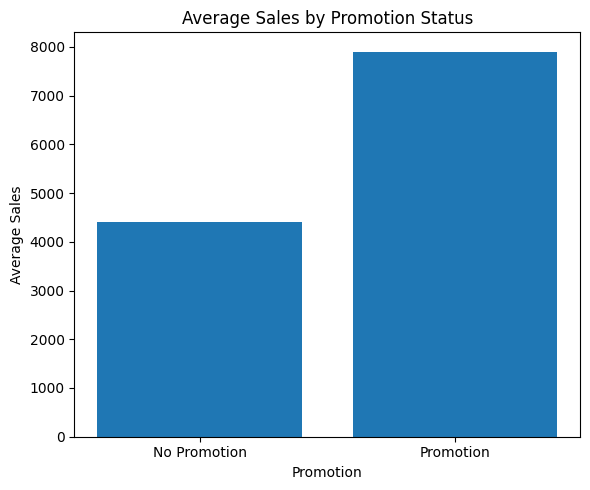

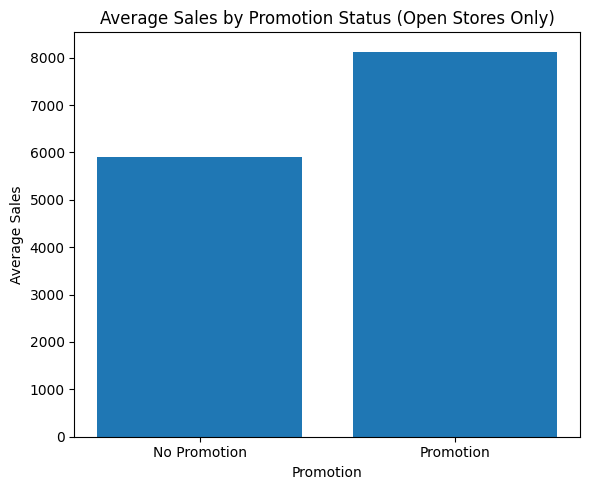

In [13]:
# =============================================================================
# STEP 19: Promotion Effect
# =============================================================================
# Compare average sales between promotional and non-promotional days.

promo_summary = (
    sales_data
    .groupby("promo")["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        count="count"
    )
)

print("\n" + "=" * 60)
print("PROMOTION EFFECT")
print("=" * 60)

print(promo_summary)
plt.figure(figsize=(6,5))

promo_mean = (
    sales_data
    .groupby("promo")["sales"]
    .mean()
)

plt.bar(
    ["No Promotion", "Promotion"],
    promo_mean.values
)

plt.title("Average Sales by Promotion Status")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

open_sales = sales_data[
    sales_data["open"] == 1
]
promo_mean_open = (
    open_sales
    .groupby("promo")["sales"]
    .mean()
)

plt.figure(figsize=(6,5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_mean_open.values
)

plt.title("Average Sales by Promotion Status (Open Stores Only)")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()




STATE HOLIDAY EFFECT
                mean_sales  median_sales    std_sales   count
state_holiday                                                
0              5910.960163        5837.0  3688.649261  606599
a               267.943364           0.0  2023.045780   11265
b               271.866617           0.0  2122.858835    4056
c               202.737426           0.0  1723.668727    2704


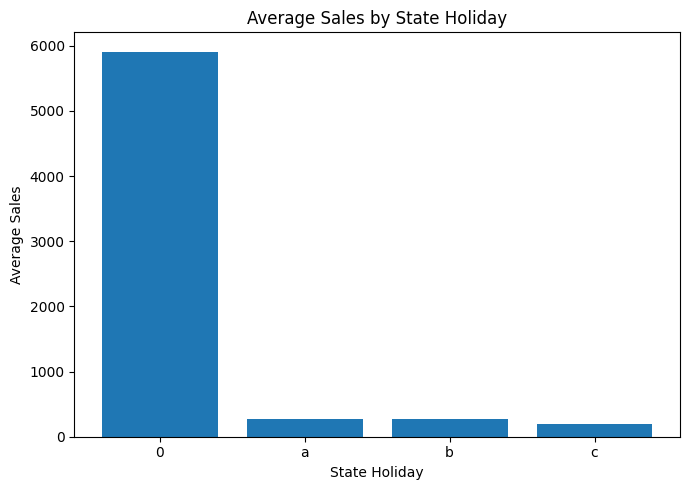

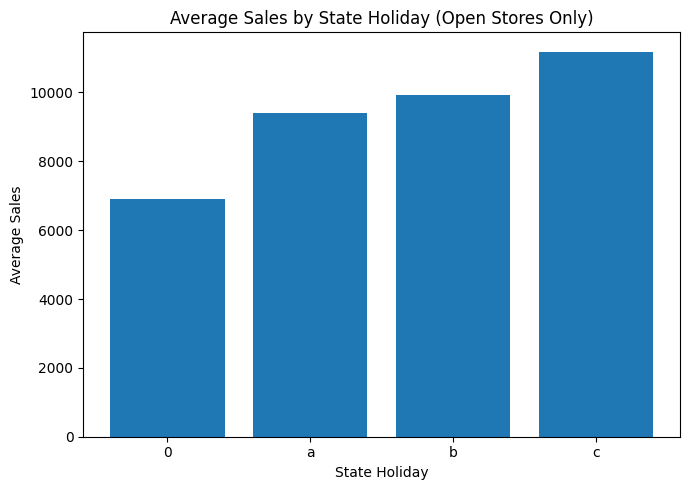

In [14]:
# =============================================================================
# STEP 20: State Holiday Effect
# =============================================================================
# Compare average sales across different state holiday types.

holiday_summary = (
    sales_data
    .groupby("state_holiday")["sales"]
    .agg(
        mean_sales="mean",
        median_sales="median",
        std_sales="std",
        count="count"
    )
)

print("\n" + "=" * 60)
print("STATE HOLIDAY EFFECT")
print("=" * 60)

print(holiday_summary)

holiday_mean = (
    sales_data
    .groupby("state_holiday")["sales"]
    .mean()
)

plt.figure(figsize=(7,5))

plt.bar(
    holiday_mean.index,
    holiday_mean.values
)

plt.title("Average Sales by State Holiday")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

holiday_mean_open = (
    open_sales
    .groupby("state_holiday")["sales"]
    .mean()
)

plt.figure(figsize=(7,5))

plt.bar(
    holiday_mean_open.index,
    holiday_mean_open.values
)

plt.title("Average Sales by State Holiday (Open Stores Only)")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()


#When all observations are included, average sales on state holidays appear substantially lower than on normal trading days.
#However, after excluding closed-store observations, sales during state holidays exceed those on normal trading days. This suggests that the apparent decline in holiday sales is primarily due to widespread store closures rather than reduced customer demand.

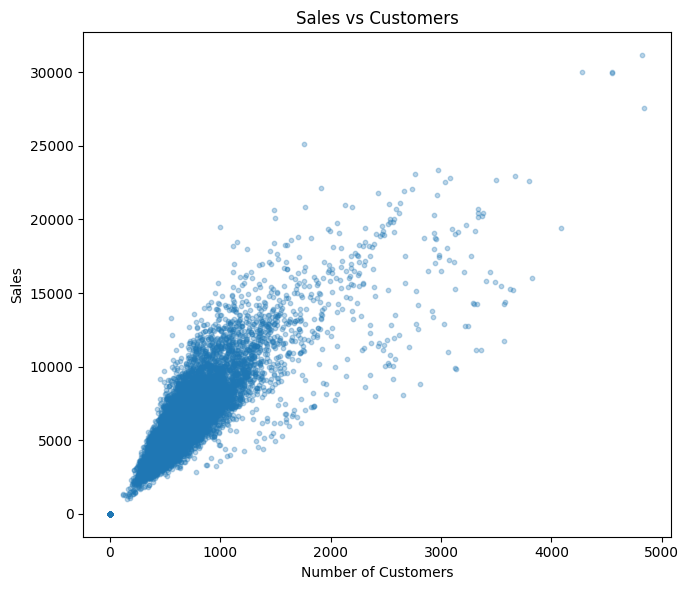


CUSTOMERS AND SALES CORRELATION
Pearson correlation: 0.8822


In [15]:
# =============================================================================
# STEP 21: Relationship Between Customers and Sales
# =============================================================================
# Explore the relationship between customer numbers and sales.

sample_data = sales_data.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(7,6))

plt.scatter(
    sample_data["customers"],
    sample_data["sales"],
    alpha=0.3,
    s=10
)

plt.title("Sales vs Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

correlation = sales_data["customers"].corr(
    sales_data["sales"]
)

print("\n" + "=" * 60)
print("CUSTOMERS AND SALES CORRELATION")
print("=" * 60)

print(f"Pearson correlation: {correlation:.4f}")

In [9]:
# future data  inspection
# =============================================================================
# STEP 1: Dataset Overview
# =============================================================================

print("\n" + "=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(future_data.shape)

print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
future_data.info()

print("\n" + "=" * 60)
print("VARIABLE DATA TYPES")
print("=" * 60)
print(future_data.dtypes)

print("\n" + "=" * 60)
print("FIRST FIVE OBSERVATIONS")
print("=" * 60)
print(future_data.head())

# =============================================================================
# STEP 2: Date and Data Quality
# =============================================================================

future_data["date"] = pd.to_datetime(future_data["date"])

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)

print("Start Date :", future_data["date"].min())
print("End Date   :", future_data["date"].max())
print("Unique Dates:", future_data["date"].nunique())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(future_data.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE OBSERVATIONS")
print("=" * 60)

print(
    "Entire duplicated rows:",
    future_data.duplicated().sum()
)

print(
    "Duplicate store-date pairs:",
    future_data.duplicated(
        subset=["store_id", "date"]
    ).sum()
)

# =============================================================================
# STEP 3: Categorical Variables
# =============================================================================

print("\n" + "=" * 60)
print("OPEN STATUS")
print("=" * 60)

print(future_data["open"].value_counts())
print(future_data["open"].value_counts(normalize=True))


print("\nPROMOTION STATUS")

print(future_data["promo"].value_counts())
print(future_data["promo"].value_counts(normalize=True))

print("\nSTATE HOLIDAY")

print(future_data["state_holiday"].value_counts())

print("\nSCHOOL HOLIDAY")

print(future_data["school_holiday"].value_counts())
print(future_data["school_holiday"].value_counts(normalize=True))

# =============================================================================
# STEP 4: Store-Level Observations
# =============================================================================

store_counts = (
    future_data
    .groupby("store_id")["date"]
    .count()
)

print("\n" + "=" * 60)
print("STORE-LEVEL OBSERVATIONS")
print("=" * 60)

print(store_counts.describe())

print("\nNumber of stores:",
      store_counts.shape[0])

print("Stores with complete history:",
      (store_counts == store_counts.max()).sum())

# =============================================================================
# STEP 5: Customers Availability
# =============================================================================

print("\n" + "=" * 60)
print("CUSTOMERS VARIABLE")
print("=" * 60)

print("Missing values:",
      future_data["customers"].isnull().sum())

print("Total records:",
      len(future_data))
# =============================================================================
# STEP 6: Missing Open Status
# =============================================================================
# Display records where the store open status is missing.

print("\n" + "=" * 60)
print("MISSING OPEN STATUS")
print("=" * 60)

print(
    future_data[
        future_data["open"].isna()
    ]
)
store379_history = sales_data[
    sales_data["store_id"] == "store_379"
].copy()

store379_history["date"] = pd.to_datetime(store379_history["date"])

store379_history = store379_history.sort_values("date")

print(
    store379_history.tail(30)[
        ["date", "open", "sales", "promo"]
    ]
)


DATASET DIMENSIONS
(40560, 7)

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40560 entries, 0 to 40559
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        40560 non-null  object 
 1   date            40560 non-null  object 
 2   open            40549 non-null  float64
 3   promo           40560 non-null  int64  
 4   state_holiday   40560 non-null  int64  
 5   school_holiday  40560 non-null  int64  
 6   customers       0 non-null      float64
dtypes: float64(2), int64(3), object(2)
memory usage: 2.2+ MB

VARIABLE DATA TYPES
store_id           object
date               object
open              float64
promo               int64
state_holiday       int64
school_holiday      int64
customers         float64
dtype: object

FIRST FIVE OBSERVATIONS
  store_id        date  open  promo  state_holiday  school_holiday  customers
0  store_1  2015-09-17   1.0      1              0     

In [16]:
# =============================================================================
# METADATA INITIAL DATA INSPECTION
# =============================================================================

import pandas as pd

# =============================================================================
# STEP 1: Dataset Dimensions
# =============================================================================

print("\n" + "=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print(meta_data.shape)

# =============================================================================
# STEP 2: Dataset Structure
# =============================================================================

print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

meta_data.info()

print("\n" + "=" * 60)
print("VARIABLE DATA TYPES")
print("=" * 60)

print(meta_data.dtypes)

# =============================================================================
# STEP 3: First Five Observations
# =============================================================================

print("\n" + "=" * 60)
print("FIRST FIVE OBSERVATIONS")
print("=" * 60)

print(meta_data.head())

# =============================================================================
# STEP 4: Missing Values
# =============================================================================

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(meta_data.isnull().sum())

# =============================================================================
# STEP 5: Duplicate Observations
# =============================================================================

print("\n" + "=" * 60)
print("DUPLICATE OBSERVATIONS")
print("=" * 60)

print("Entire duplicated rows:",
      meta_data.duplicated().sum())

print("Duplicate store_id:",
      meta_data["store_id"].duplicated().sum())

# =============================================================================
# STEP 6: Numerical Summary
# =============================================================================

print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

print(meta_data.describe())

# =============================================================================
# STEP 7: Categorical Summary
# =============================================================================

print("\n" + "=" * 60)
print("STORE TYPE DISTRIBUTION")
print("=" * 60)

print(meta_data["store_type"].value_counts())

print("\nPercentage:")

print(
    meta_data["store_type"]
    .value_counts(normalize=True)
    .round(4)
)

print("\n" + "=" * 60)
print("ASSORTMENT DISTRIBUTION")
print("=" * 60)

print(meta_data["assortment"].value_counts())

print("\nPercentage:")

print(
    meta_data["assortment"]
    .value_counts(normalize=True)
    .round(4)
)

# =============================================================================
# STEP 8: Competition Distance
# =============================================================================

print("\n" + "=" * 60)
print("COMPETITION DISTANCE")
print("=" * 60)

print(meta_data["competition_distance"].describe())

print("\nMinimum distance:",
      meta_data["competition_distance"].min())

print("Maximum distance:",
      meta_data["competition_distance"].max())

# =============================================================================
# STEP 9: Store Coverage
# =============================================================================

sales_stores = set(sales_data["store_id"])
future_stores = set(future_data["store_id"])
meta_stores = set(meta_data["store_id"])

print("\n" + "=" * 60)
print("STORE COVERAGE CHECK")
print("=" * 60)

print("Stores in sales_data :", len(sales_stores))
print("Stores in future_data:", len(future_stores))
print("Stores in metadata   :", len(meta_stores))

print("\nStores only in sales_data:")
print(sales_stores - meta_stores)

print("\nStores only in future_data:")
print(future_stores - meta_stores)

print("\nStores only in metadata:")
print(meta_stores - sales_stores)

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("METADATA INSPECTION COMPLETED")
print("=" * 60)

print("Total stores :", len(meta_stores))
print("Missing values:")
print(meta_data.isnull().sum().sum())
print("Duplicate rows:", meta_data.duplicated().sum())


DATASET DIMENSIONS
(676, 4)

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store_id              676 non-null    object 
 1   store_type            676 non-null    object 
 2   assortment            676 non-null    object 
 3   competition_distance  675 non-null    float64
dtypes: float64(1), object(3)
memory usage: 21.3+ KB

VARIABLE DATA TYPES
store_id                 object
store_type               object
assortment               object
competition_distance    float64
dtype: object

FIRST FIVE OBSERVATIONS
  store_id store_type assortment  competition_distance
0  store_1          c          a                1270.0
1  store_2          a          a               14130.0
2  store_3          a          c               24000.0
3  store_4          a          a                7520.0
4  store_5          a     

In [17]:
#  Data Cleaning
# =============================================================================
# STEP 1: Data Type Conversion
# =============================================================================

# Convert date columns
sales_data["date"] = pd.to_datetime(sales_data["date"])
future_data["date"] = pd.to_datetime(future_data["date"])

# Convert categorical variables in sales_data
sales_data[
    ["store_id", "state_holiday"]
] = sales_data[
    ["store_id", "state_holiday"]
].astype("category")

# Convert categorical variables in future_data
future_data[
    ["store_id", "state_holiday"]
] = future_data[
    ["store_id", "state_holiday"]
].astype("category")

# Convert categorical variables in metadata
meta_data[
    ["store_id", "store_type", "assortment"]
] = meta_data[
    ["store_id", "store_type", "assortment"]
].astype("category")

# =============================================================================
# STEP 2: Missing Value Summary
# =============================================================================

print("=" * 60)
print("MISSING VALUES BEFORE CLEANING")
print("=" * 60)

print("\nSales Data")
print(sales_data.isnull().sum())

print("\nFuture Data")
print(future_data.isnull().sum())

print("\nMetadata")
print(meta_data.isnull().sum())

# Fill missing values in the 'open' column.
# The missing values are limited to 11 consecutive records of store_379.
# Based on the historical operating pattern of this store,
# the store is normally open on weekdays and Saturdays.
# Therefore, the missing values are imputed as 1 (open).

future_data.loc[
    (future_data["store_id"] == "store_379") &
    (future_data["open"].isna()),
    "open"
] = 1

# Fill the missing competition distance using the median.
# Only one value is missing and the variable is positively skewed,
# therefore the median provides a robust estimate.

median_distance = meta_data["competition_distance"].median()

meta_data["competition_distance"] = (
    meta_data["competition_distance"]
    .fillna(median_distance)
)

# The 'customers' column in future_data is intentionally left unchanged.
# Customer numbers are unavailable for the forecasting horizon and
# will not be used as an input feature during model development.

# =============================================================================
# STEP 3: Validation
# =============================================================================

print("\n" + "=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

print("\nSales Data")
print(sales_data.isnull().sum())

print("\nFuture Data")
print(future_data.isnull().sum())

print("\nMetadata")
print(meta_data.isnull().sum())

MISSING VALUES BEFORE CLEANING

Sales Data
store_id          0
date              0
sales             0
customers         0
open              0
promo             0
state_holiday     0
school_holiday    0
weekday           0
dtype: int64

Future Data
store_id              0
date                  0
open                 11
promo                 0
state_holiday         0
school_holiday        0
customers         40560
dtype: int64

Metadata
store_id                0
store_type              0
assortment              0
competition_distance    1
dtype: int64

MISSING VALUES AFTER CLEANING

Sales Data
store_id          0
date              0
sales             0
customers         0
open              0
promo             0
state_holiday     0
school_holiday    0
weekday           0
dtype: int64

Future Data
store_id              0
date                  0
open                  0
promo                 0
state_holiday         0
school_holiday        0
customers         40560
dtype: int64

Metadata
sto

In [14]:
# =============================================================================
# STEP 4: Merge Metadata
# =============================================================================
# Merge metadata into the historical sales data.

sales_clean = sales_data.merge(
    meta_data,
    on="store_id",
    how="left"
)
# Merge metadata into the future dataset.

future_clean = future_data.merge(
    meta_data,
    on="store_id",
    how="left"
)

# =============================================================================
# STEP 5: Merge Validation
# =============================================================================

print("\n" + "=" * 60)
print("DATASET SHAPES AFTER MERGE")
print("=" * 60)

print("Sales before merge :", sales_data.shape)
print("Sales after merge  :", sales_clean.shape)

print()

print("Future before merge:", future_data.shape)
print("Future after merge :", future_clean.shape)

print("\n" + "=" * 60)
print("MISSING VALUES AFTER MERGE")
print("=" * 60)

print("\nSales Clean")
print(sales_clean.isnull().sum())

print("\nFuture Clean")
print(future_clean.isnull().sum())

print("\n" + "=" * 60)
print("NEW VARIABLES")
print("=" * 60)

print(sales_clean.columns)


DATASET SHAPES AFTER MERGE
Sales before merge : (624624, 9)
Sales after merge  : (624624, 12)

Future before merge: (40560, 7)
Future after merge : (40560, 10)

MISSING VALUES AFTER MERGE

Sales Clean
store_id                0
date                    0
sales                   0
customers               0
open                    0
promo                   0
state_holiday           0
school_holiday          0
weekday                 0
store_type              0
assortment              0
competition_distance    0
dtype: int64

Future Clean
store_id                    0
date                        0
open                        0
promo                       0
state_holiday               0
school_holiday              0
customers               40560
store_type                  0
assortment                  0
competition_distance        0
dtype: int64

NEW VARIABLES
Index(['store_id', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'weekday', 'store_type'

In [ ]:
from pathlib import Path
import pandas as pd

raw_dir = Path("..") / "data" / "raw"
sales_data_path = raw_dir / "sales_data.csv"
future_data_path = raw_dir / "future_values.csv"
meta_data_path = raw_dir / "metadata.csv"

sales_data = pd.read_csv(sales_data_path, low_memory=False)
future_data = pd.read_csv(future_data_path, low_memory=False)
meta_data = pd.read_csv(meta_data_path, low_memory=False)

sales_data["date"] = pd.to_datetime(sales_data["date"])
future_data["date"] = pd.to_datetime(future_data["date"])

future_data.loc[
    (future_data["store_id"] == "store_379") &
    (future_data["open"].isna()),
    "open"
] = 1

median_distance = meta_data["competition_distance"].median()
meta_data["competition_distance"] = meta_data["competition_distance"].fillna(median_distance)

sales_clean = sales_data.merge(meta_data, on="store_id", how="left")
future_clean = future_data.merge(meta_data, on="store_id", how="left")

output_dir = Path(".")
if output_dir.name != "notebooks":
    output_dir = output_dir / "notebooks"
output_dir.mkdir(parents=True, exist_ok=True)

sales_clean.to_csv(output_dir / "sales-meta.csv", index=False)
future_clean.to_csv(output_dir / "future-meta.csv", index=False)

print("Saved:")
print(output_dir / "sales-meta.csv")
print(output_dir / "future-meta.csv")

Saved:
notebooks\sales-meta.csv
notebooks\future-meta.csv


: 